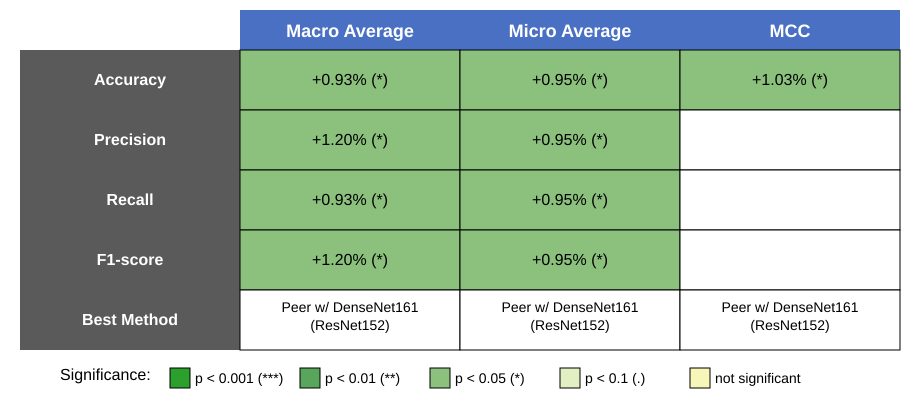

In [22]:
import svgwrite
import os
from IPython.display import SVG, display

# Create the SVG drawing
dwg = svgwrite.Drawing(size=("920px", "400px"), profile='tiny')
font_family = "Arial"

# Colors
dark_green = "#2ca02c"
medium_green = "#58a55c"
light_green = "#8bc17d"
yellow_green = "#e2efc2"
very_light_yellow = "#f6f6b9"
dark_blue = "#4a70c4"
gray = "#5a5a5a"
white = "#ffffff"

# Header
# dwg.add(dwg.text("Highest Performance Increase on HyperKvasir Dataset", insert=("50%", 40),
#                  text_anchor="middle", font_size="28px", font_weight="bold", font_family=font_family))

# Column Headers
columns = ["Macro Average", "Micro Average", "MCC"]
for i, col in enumerate(columns):
    dwg.add(dwg.rect(insert=(240 + i * 220, 10), size=(220, 40), fill=dark_blue))
    dwg.add(dwg.text(col, insert=(350 + i * 220, 37), text_anchor="middle", fill=white,
                     font_size="18px", font_family=font_family, font_weight="bold"))

# Row Headers and Data
rows = ["Accuracy", "Precision", "Recall", "F1-score", "Best Method"]
data = [
    [("+0.93% (*)", light_green), ("+0.95% (*)", light_green), ("+1.03% (*)", light_green)],
    [("+1.20% (*)", light_green), ("+0.95% (*)", light_green), ("", "")],
    [("+0.93% (*)", light_green), ("+0.95% (*)", light_green), ("", "")],
    [("+1.20% (*)", light_green), ("+0.95% (*)", light_green), ("", "")],
    [("Peer w/ DenseNet161\n(ResNet152)", white), ("Peer w/ DenseNet161\n(ResNet152)", white), ("Peer w/ DenseNet161\n(ResNet152)", white)],
]

for j, row in enumerate(rows):
    y = 50 + j * 60
    dwg.add(dwg.rect(insert=(20, y), size=(220, 60), fill=gray))
    dwg.add(dwg.text(row, insert=(130, y + 35), text_anchor="middle", fill=white,
                     font_size="16px", font_family=font_family, font_weight="bold"))

    for i in range(3):
        x = 240 + i * 220
        bg_color = data[j][i][1] if data[j][i][1] else white
        dwg.add(dwg.rect(insert=(x, y), size=(220, 60), fill=bg_color, stroke="black"))
        if row == "Best Method":
            method_lines = data[j][i][0].split("\n")
            for k, line in enumerate(method_lines):
                dwg.add(dwg.text(line, insert=(x + 110, y + 22 + 18 * k), text_anchor="middle",
                                 font_size="14px", font_family=font_family))
        else:
            dwg.add(dwg.text(data[j][i][0], insert=(x + 110, y + 35), text_anchor="middle",
                             font_size="16px", font_family=font_family))

# Significance Legend
dwg.add(dwg.text("Significance:", insert=(60, 380), font_size="16px", font_family=font_family))
legend_colors = [dark_green, medium_green, light_green, yellow_green, very_light_yellow]
legend_texts = ["p < 0.001 (***)", "p < 0.01 (**)", "p < 0.05 (*)", "p < 0.1 (.)", "not significant"]
for i, (color, text) in enumerate(zip(legend_colors, legend_texts)):
    x = 170 + i * 130
    dwg.add(dwg.rect(insert=(x, 368), size=(20, 20), fill=color, stroke="black"))
    dwg.add(dwg.text(text, insert=(x + 25, 383), font_size="14px", font_family=font_family))

# Key Finding box
# dwg.add(dwg.rect(insert=(100, 470), size=(800, 80), fill="#f5f9ff", stroke="#b4cceb", rx=10, ry=10))
# dwg.add(dwg.text("Key Finding", insert=(500, 495), text_anchor="middle", font_size="18px",
#                  font_family=font_family, font_weight="bold"))
# key_finding = ("Peer Explanation with DenseNet161 as teacher and ResNet152 as student\n"
#                "consistently delivers the highest performance increases across all metrics.")
# for i, line in enumerate(key_finding.split("\n")):
#     dwg.add(dwg.text(line, insert=(500, 520 + i * 20), text_anchor="middle", font_size="14px",
#                      font_family=font_family))

# Save SVG
svg_path = os.path.join(os.getcwd(), "performance_increase.svg")
dwg.saveas(svg_path)
display(SVG(svg_path))